<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/hau/EDA-US-Baby-Names/us_baby_names.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân tích dữ liệu về tên trẻ sơ sinh ở Hoa Kì từ 1880 đến 2010

## 1 Định nghĩa vấn đề

Mô tả
* Phạm vi: Dữ liệu về tên trẻ em được đặt tại Hoa Kỳ từ năm 1880 đến 2010, được thu thập và công bố bởi Cơ quan An sinh Xã hội Hoa Kỳ (SSA).

* Kích thước: Gồm gần 1800000 bản ghi (mẫu), được tổng hợp từ các tệp hàng năm (mỗi năm một file).
* Đặc điểm: có 4 trường dữ liệu thông tin về tên và số lượng trẻ em

Dữ liệu vào
* name:	Tên trẻ em được đặt
* sex:	Giới tính của trẻ (M: Nam, F: Nữ)
* births: Số lượng trẻ sinh có tên đó trong năm
* year:	Năm sinh tương ứng

Dữ liệu ra (Kết quả phân tích):
* Các phát hiện về xu hướng đặt tên trẻ em tại Hoa Kỳ giai đoạn 1880–2010, dựa trên dữ liệu của Cơ quan An sinh Xã hội Mỹ (SSA).


Mục tiêu phân tích:


+ Khám phá xu hướng đặt tên trẻ em ở Mỹ trong hơn 130 năm (1880–2010)
+ Tìm hiểu sự phổ biến của từng tên theo thời gian;
+ Đánh giá sự đa dạng văn hóa và thay đổi giới tính trong đặt tên;
+ Xác định các mô hình dài hạn (long-term patterns) về độ phổ biến, vòng đời của tên, và tác động xã hội.



## 2 Chuẩn bị  xử lí

### 2.1 Khai báo thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### 2.2 Nạp dữ liệu

In [ ]:
# kiểm tra file
names1880 = pd.read_csv("/content/drive/MyDrive/ptdl/tuan6/babynames/yob1880.txt",names=["name", "sex", "births"])


In [ ]:
names1880

,name,sex,births
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


In [ ]:
# tổng số ca sinh trong năm 1880 theo giới tính
names1880.groupby("sex")["births"].sum()

,births
sex,
F,90993
M,110493


In [ ]:
# tập hợp dữ liệu vào dataframe duy nhất và thêm cột 'year'
pieces = []
for year in range(1880, 2011):
 path = f"/content/drive/MyDrive/ptdl/tuan6/babynames/yob{year}.txt"
 frame = pd.read_csv(path, names=["name", "sex", "births"])
 # Add a column for the year
 frame["year"] = year
 pieces.append(frame)
# Concatenate everything into a single DataFrame
names = pd.concat(pieces, ignore_index=True)


In [ ]:
names

### 2.3 Thông tin tổng quát về dữ liệu

In [ ]:
names.info()

Thông tin cơ bản của bộ dữ liệu

* Dữ liệu có 4 tính chất (cột) để phân tích, bao gồm:
name, sex, births, và year.

* Các giá trị gồm 2 cột kiểu object (name, sex) và 2 cột kiểu int64 (births, year).

* Tổng số dòng dữ liệu là 1,690,784 bản ghi, tương ứng với số lượng tên được thống kê từ năm 1880 đến năm 2010.

Bộ dữ liệu này không có cột phân lớp, mà mang tính thống kê mô tả. Trong đó, biến chính để phân tích là births - biểu thị số trẻ sinh mang tên cụ thể trong từng năm và giới tính.

## 3 EDA và trực quan hóa

Câu hỏi: sự thay đổi về tổng số trẻ sinh theo giới tính qua các giai đoạn (1880–2010) là như thế nào?

In [ ]:
# tập hợp dữ liệu theo năm và giới tính bằng pivot
total_births = names.pivot_table("births",
    index="year", columns="sex", aggfunc=sum)
total_births.head()

In [ ]:
total_births.plot(title="Total births by sex and year")
plt.savefig("total_births.png")


Nhận xét:
* Giai đoạn 1880–1960:

    * Tỉ lệ sinh tăng mạnh

* Giai đoạn 1960–1980:

    * Tỉ lệ sinh giảm mạnh
* Giai đoạn 1980-2010
    * Tỉ lệ sinh tăng dần

Kết luận: Tỉ lệ sinh tổng thể cho thấy mối liên hệ chặt chẽ với các sự kiện kinh tế—xã hội—lịch sử lớn:

* Giai đoạn Bùng nổ: Tỉ lệ sinh tăng đột biến vào những năm 1910–1920 và đạt đỉnh cao lịch sử trong giai đoạn 1945–1960(thời kỳ Baby Boomers).

Giai đoạn Suy giảm: Tỉ lệ sinh giảm mạnh từ khoảng 1960–1980 , cho thấy sự thay đổi lớn trong hành vi sinh sản của xã hội(khủng hoảng 1970s)

Giai đoạn Phục hồi/Ổn định: Tỉ lệ sinh phục hồi và đạt đỉnh thứ hai vào khoảng năm 2000, sau đó có xu hướng giảm nhẹ, cho thấy sự bão hòa ở mức sinh cao trong xã hội hiện đại.

Sau khi đã quan sát sự thay đổi về tổng số trẻ sinh theo giới tính qua các giai đoạn (1880–2010), ta tiếp tục đi sâu vào xu hướng đặt tên cụ thể của người dân Mỹ.

Câu hỏi: Xác định những tên nào phổ biến nhất mỗi thập kỷ?  Những tên xuất hiện ngắn hạn (short-lived) khác gì so với tên phổ biến lâu dài (long-lived)?


tính tỉ lệ sinh

In [ ]:
# tỷ lệ sinh của mỗi tên so với tổng số ca sinh trong năm và giới tính đó.

def add_prop(group):
  group["prop"] = group["births"] / group["births"].sum()
  return group
names = names.groupby(["year", "sex"], group_keys=False).apply(add_prop).reset_index()


In [ ]:
names

In [ ]:
# xác minh tổng prop là 1 trong tất cả các nhóm
names.groupby(["year", "sex"])["prop"].sum()

Tiến hành lấy ra 1000 dòng dữ liệu đầu tiên theo giới tính và năm sinh

Mục tiêu là tập trung vào nhóm tên có ảnh hưởng lớn nhất đến xu hướng chung, loại bỏ nhiễu từ các tên hiếm gặp.

In [ ]:
# 1000 tên hàng đầu cho mỗi cặp giới tính/năm

top1000 = names.groupby(["year", "sex"]).apply(lambda x: x.head(1000))
top1000 = top1000.reset_index(drop=True)

In [ ]:
# bỏ chỉ số nhóm vì không cần cho việc phân tích
top1000 = top1000.reset_index(drop=True)
top1000.head(10)


In [ ]:
# Tạo cột 'decade' (thập kỷ)
top1000["decade"] = (top1000["year"] // 10) * 10

# Tổng số ca sinh mỗi tên trong từng thập kỷ và giới tính
decade_grouped = top1000.groupby(["decade", "sex", "name"])["births"].sum().reset_index()

# Lấy top 10 tên phổ biến nhất mỗi thập kỷ cho từng giới tính
top10_decade = (
    decade_grouped
    .sort_values(["decade", "sex", "births"], ascending=[True, True, False])
    .groupby(["decade", "sex"])
    .head(10)
)
for decade in sorted(top10_decade["decade"].unique()):
    print(f"\n===== Thập kỷ {decade}s =====")
    for sex in ['F', 'M']:
        sub = top10_decade[(top10_decade["decade"] == decade) & (top10_decade["sex"] == sex)]
        print(f"\nGiới tính: {'Nữ' if sex == 'F' else 'Nam'}")
        print(sub[["name", "births"]].to_string(index=False))



===== Thập kỷ 1880s =====

Giới tính: Nữ
     name  births
     Mary   91672
     Anna   38159
     Emma   25404
Elizabeth   25007
 Margaret   21800
   Minnie   21724
      Ida   18283
   Bertha   18263
    Clara   17717
    Alice   17141

Giới tính: Nam
   name  births
   John   89949
William   84881
  James   54058
 George   47651
Charles   46658
  Frank   30967
 Joseph   26294
  Henry   24139
 Robert   24079
 Thomas   23750

===== Thập kỷ 1890s =====

Giới tính: Nữ
     name  births
     Mary  131138
     Anna   55260
 Margaret   37939
    Helen   37801
Elizabeth   33880
     Ruth   32868
 Florence   32345
    Ethel   31453
     Emma   28652
    Marie   25853

Giới tính: Nam
   name  births
   John   80669
William   72245
  James   50723
 George   43359
Charles   36848
 Joseph   29000
  Frank   28718
 Robert   26150
 Edward   22032
  Henry   21664

===== Thập kỷ 1900s =====

Giới tính: Nữ
     name  births
     Mary  161506
    Helen   69426
 Margaret   57921
     Anna   54916
    

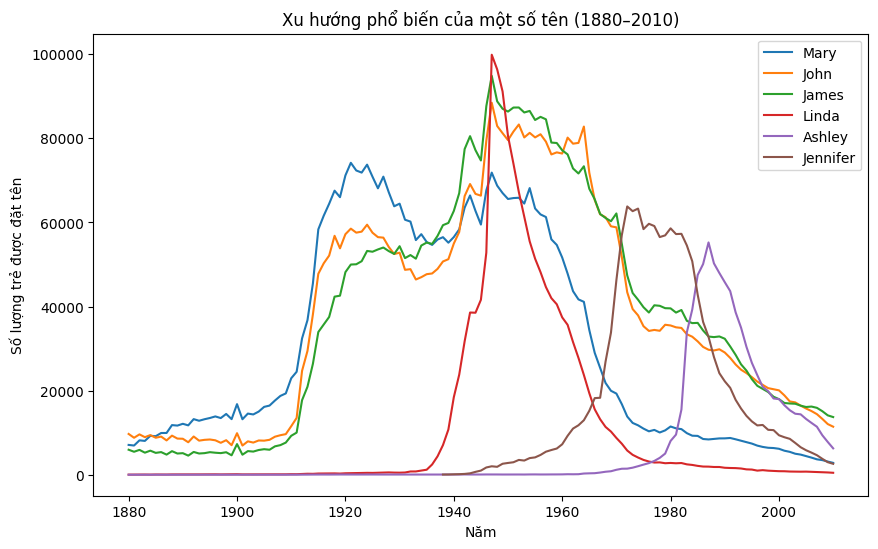

In [ ]:

# Lấy dữ liệu 1 số tên tiêu biểu
selected_names = ['Mary', 'John', 'James', 'Linda', 'Ashley', 'Jennifer']

# Gom dữ liệu theo năm, tên, giới tính
name_trends = top1000[top1000['name'].isin(selected_names)]
name_trends = name_trends.groupby(['year', 'name'])['births'].sum().reset_index()

plt.figure(figsize=(10,6))
for name in selected_names:
    subset = name_trends[name_trends['name'] == name]
    plt.plot(subset['year'], subset['births'], label=name)

plt.title('Xu hướng phổ biến của một số tên (1880–2010)')
plt.xlabel('Năm')
plt.ylabel('Số lượng trẻ được đặt tên')
plt.legend()
plt.show()


Nhận xét

Tên phổ biến lâu dài (long-lived)

* Các tên như Mary, John, William, James, Robert, Michael duy trì độ phổ biến qua nhiều thập kỷ.

* Điểm chung:

  * Có nguồn gốc Kinh Thánh hoặc cổ điển, mang ý nghĩa tích cực, quen thuộc.

  * Âm thanh dễ đọc, phù hợp trong mọi giai đoạn lịch sử.

  * Được truyền qua nhiều thế hệ, thể hiện giá trị văn hóa bền vững.

  → Đây là nhóm tên có tính “văn hóa nền tảng” – thường được xem là an toàn, tôn trọng truyền thống.

Tên xuất hiện ngắn hạn (short-lived)

* Điển hình là các tên như: Linda, Jennifer, Jessica, Ashley, Madison

* Đặc điểm:

  * Bùng nổ trong 1–2 thập kỷ rồi giảm nhanh.

  * Thường liên quan phong trào văn hóa đại chúng (phim, ca sĩ, nhân vật nổi tiếng).

  * Khi thế hệ đó trưởng thành, tên trở nên “cũ kỹ”, ít được đặt lại.


Câu hỏi: Mức độ phổ biến của một số tên phổ biến (như John, Harry, Mary, Marilyn) có thay đổi theo thời gian hay không?

In [ ]:
# tổng số ca sinh theo năm và tên
total_births = top1000.pivot_table("births", index="year",
columns="name",
aggfunc=sum)

/tmp/ipython-input-2690042770.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = top1000.pivot_table("births", index="year",


In [ ]:
total_births.info()


<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6862 entries, Aaden to Zuri
dtypes: float64(6862)
memory usage: 6.9 MB


Nhận xét:Dữ liệu total_births là một DataFrame dạng bảng tổng hợp (pivot table) với:

* Chỉ số (Index): 131 giá trị tương ứng với các năm từ 1880 đến 2010 → thể hiện theo dõi liên tục qua từng năm.

* Số cột (Columns): 6.862 tên, từ “Aaden” đến “Zuri”, biểu diễn các tên trẻ em được ghi nhận trong dữ liệu.

* Kiểu dữ liệu: float64 cho toàn bộ các cột → do có thể có giá trị NaN (thiếu dữ liệu) khi một tên không xuất hiện trong năm nào đó.

* Dung lượng bộ nhớ: ~6.9 MB, cho thấy đây là một tập dữ liệu khá lớn, phản ánh xu hướng đặt tên qua hơn một thế kỷ.

Tổng hợp và trực quan hóa dữ liệu

In [ ]:
# Chọn những tên có phần trăm xuất hiện cao
subset = total_births[["John", "Harry", "Mary", "Marilyn"]]


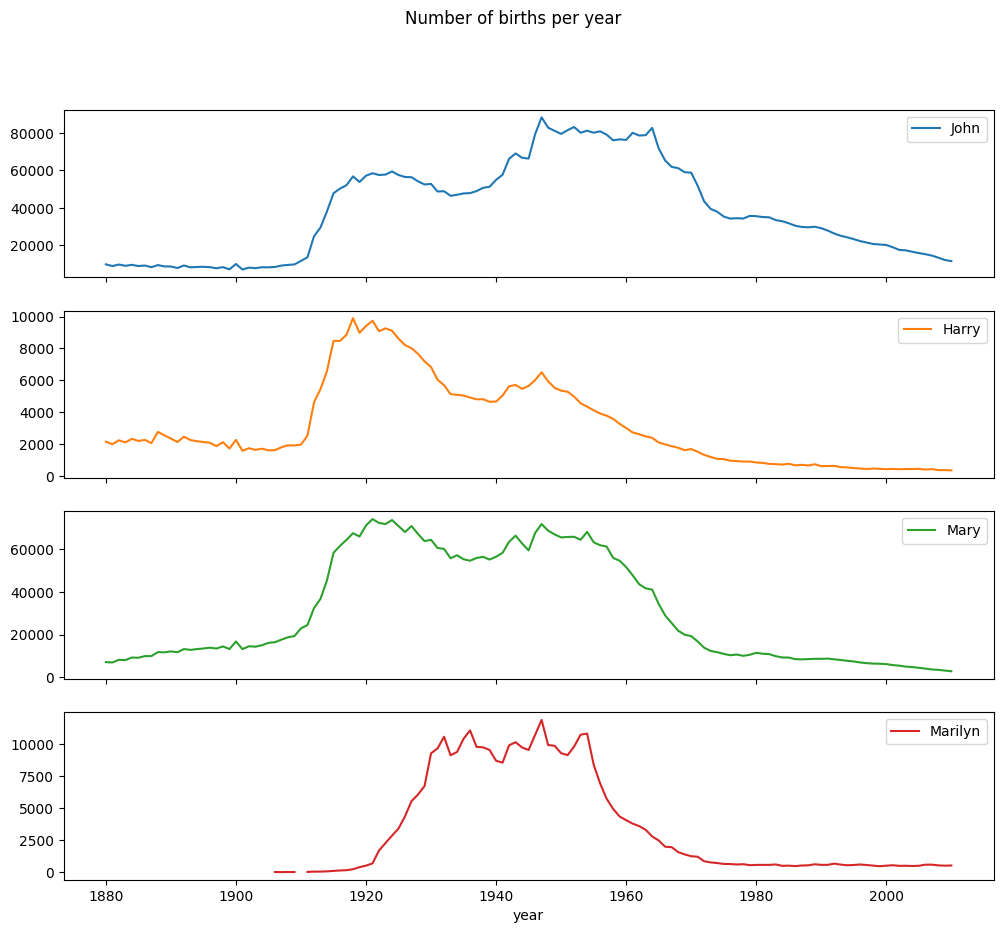

In [ ]:
subset.plot(subplots=True, figsize=(12, 10), title="Number of births per year")
plt.savefig("births.png")

Khi quan sát biểu đồ số lượng trẻ được đặt tên John, Harry, Mary, Marilyn theo thời gian, ta nhận thấy:

* Tất cả các tên này đều có mức độ phổ biến cao trong khoảng từ 1900 đến 1980, nhưng đều giảm mạnh sau năm 1980.

* Một số tên như Mary từng là tên phổ biến nhất trong nhiều thập kỷ, nhưng dần mất đi vị thế trong những năm gần đây.
Kết luận (vì sao lại như vậy):

Xu hướng giảm dần này phản ánh sự thay đổi trong thị hiếu và văn hóa đặt tên của người Mỹ:

* Những cái tên này không còn được ưa chuộng nữa, ít cha mẹ chọn tên phổ biến cho con cái.
* Sự thay đổi này phản ánh thị hiếu đặt tên chuyển dịch theo thời gian, chịu ảnh hưởng bởi xu hướng văn hóa, xã hội và truyền thông (ví dụ: tên diễn viên, nhân vật nổi tiếng, hoặc trào lưu từng thời kỳ).
* Nói cách khác, việc đặt tên đã bớt truyền thống hơn và trở nên linh hoạt, cá nhân hóa hơn.

Tuy nhiên, việc giảm phổ biến của một số tên riêng lẻ chưa đủ để phản ánh toàn bộ xu hướng xã hội.
Do đó, ta tiếp tục đi sâu hơn để phân tích mức độ đa dạng hóa trong đặt tên qua thời gian.

Câu hỏi đặt ra:

Độ tập trung tên có thay đổi theo thời gian không?


/tmp/ipython-input-3895888949.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = top1000.pivot_table("prop", index="year", columns="sex", aggfunc=sum)


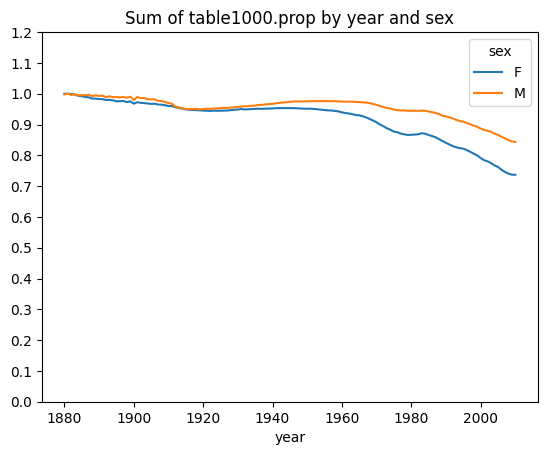

In [ ]:
# tỉ lệ sinh đại diện bởi 1000 tên phổ biến, theo năm và giới tính
table = top1000.pivot_table("prop", index="year", columns="sex", aggfunc=sum)
table.plot(title="Sum of table1000.prop by year and sex", yticks=np.linspace(0, 1.2, 13))
plt.savefig("top1000.png")

Nhận xét:

* Kết quả cho thấy cả hai giới tính đều có xu hướng giảm dần rõ rệt từ năm 1880 đến 2010.

-> Mức độ tập trung vào các tên phổ biến ngày càng giảm, hay nói cách khác, người dân có xu hướng đặt tên đa dạng hơn cho con cái — phản ánh sự thay đổi trong văn hóa và cá tính hóa lựa chọn tên.

cần bao nhiêu tên phổ biến để chiếm 50% tổng số ca sinh trong một năm nhất định?

Đầu tiên, ta xét xem vào năm 1900 và 2010, cần bao nhiêu tên phổ biến để tỉ lệ sinh đạt 50% ở con trai

In [ ]:
boys = top1000[top1000["sex"] == "M"]
girls = top1000[top1000["sex"] == "F"]


In [ ]:
# số lượng tên con trai từ năm 2010, được sắp xếp theo thứ tự phổ biến từ cao đến thấp
df = boys[boys["year"] == 2010]
df

,index,name,sex,births,year,prop,decade
260877,1676644,Jacob,M,21875,2010,0.011523,2010
260878,1676645,Ethan,M,17866,2010,0.009411,2010
260879,1676646,Michael,M,17133,2010,0.009025,2010
260880,1676647,Jayden,M,17030,2010,0.008971,2010
260881,1676648,William,M,16870,2010,0.008887,2010
...,...,...,...,...,...,...,...
261872,1677639,Camilo,M,194,2010,0.000102,2010
261873,1677640,Destin,M,194,2010,0.000102,2010
261874,1677641,Jaquan,M,194,2010,0.000102,2010
261875,1677642,Jaydan,M,194,2010,0.000102,2010


Sắp xếp tỉ lệ sinh giảm dần

In [ ]:
prop_cumsum = df["prop"].sort_values(ascending=False).cumsum()
prop_cumsum[:10]

,prop
260877,0.011523
260878,0.020934
260879,0.029959
260880,0.038930
260881,0.047817
260882,0.056579
260883,0.065155
260884,0.073414
260885,0.081528
260886,0.089621


Trong năm 2010, cần bao nhiêu tên con trai phổ biến nhất để chiếm một nửa tổng số ca sinh?

In [ ]:
prop_cumsum.searchsorted(0.5)

np.int64(116)

Nhận xét:
* Vì mảng có index = 0, nên cần cộng thêm 1 vào kết quả cuối cùng. Vì vậy cần 117 người có tên phổ biến nhất để đạt 50%

Tiếp theo, tiến hành so sánh với tổng số con trai có tên phổ biến nhất để tỉ lệ sinh đạt 50% vào năm 1900

In [ ]:
df = boys[boys.year == 1900]
in1900 = df.sort_values("prop", ascending=False).prop.cumsum()
in1900.searchsorted(0.5) + 1

np.int64(25)

Nhận xét:
* Vào năm 1900, chỉ cần 25 tên phổ biến nhất đã chiếm tới 50% tổng số ca sinh, trong khi vào năm 2010 con số này là 117 tên.

-> Trong vòng hơn một thế kỷ, mức độ đa dạng trong việc đặt tên đã tăng gần 5 lần.

Tiếp theo, ta tìm hiểu xu hướng đa dạng hóa tên có tăng theo thời gian không? Và liệu xu hướng đa dạng hóa tên gọi có khác nhau giữa con trai và con gái?


In [ ]:
def get_quantile_count(group, q=0.5):
 group = group.sort_values("prop", ascending=False)
 return group.prop.cumsum().searchsorted(q) + 1
diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)
diversity = diversity.unstack()

/tmp/ipython-input-3455365967.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)


In [ ]:
diversity.head()

sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16


Biểu đồ tổng số người để tỉ lệ sinh đạt 50%

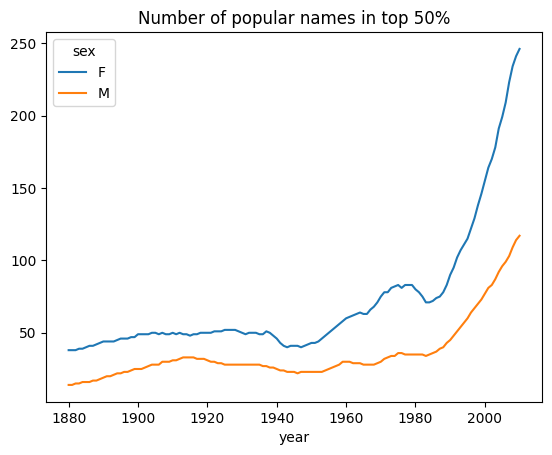

In [ ]:
diversity.plot(title="Number of popular names in top 50%")
plt.savefig("diversity.png")

Nhận xét:

* Từ năm 1880 đến khoảng 1950, số lượng tên phổ biến ít thay đổi và tương đối thấp, đặc biệt là ở nam. → Giai đoạn này, cha mẹ có xu hướng chọn tên truyền thống, lặp lại nhiều.

* Từ sau 1950, đặc biệt sau 1980, số lượng tên trong top 50% tăng mạnh, nhất là đối với bé gái. → Xu hướng đặt tên bắt đầu đa dạng hóa rõ rệt, với nhiều tên mới được sử dụng thay vì chỉ vài tên quen thuộc.

* Tên của con gái luôn đa dạng hơn con trai — đường biểu diễn của nữ luôn cao hơn nam trong suốt thời gian.

Kết luận:

* Xu hướng đa dạng hóa tên tăng dần theo thời gian, rõ nhất từ nửa sau thế kỷ 20.

* Nữ giới có mức độ đa dạng tên cao hơn nam giới.

* Nguyên nhân: Văn hoá đặt tên cho con gái thường chịu ảnh hưởng mạnh từ phim ảnh, thời trang, truyền thông, dẫn đến nhiều tên “thời thượng” và biến đổi nhanh.
* Ngược lại, tên con trai mang tính ổn định, truyền thống, kế thừa gia đình hơn.

* Sự gia tăng đa dạng tên thể hiện sự cá nhân hóa và tự do trong lựa chọn của xã hội Mỹ hiện đại — cha mẹ muốn tạo dấu ấn riêng cho con thay vì theo khuôn mẫu cũ.

Sau khi đã quan sát sự thay đổi về tổng số trẻ sinh theo giới tính qua các giai đoạn (1880–2010) và sự đa dạng trong việc đặt tên, ta tiếp tục đi sâu hơn vào một khía cạnh thú vị: sự thay đổi trong chữ cái cuối cùng của tên qua thời gian.

Liệu chữ cái cuối của tên trẻ có phản ánh sự thay đổi trong xu hướng đặt tên qua các thời kỳ hay không?
Cụ thể, những chữ cái nào trở nên phổ biến hoặc giảm dần trong các thế hệ?

Trước hết, ta tổng hợp số ca sinh theo năm, giới tính và chữ cái cuối trong tên:

In [ ]:
def get_last_letter(x):
 return x[-1]
last_letters = names["name"].map(get_last_letter)
last_letters.name = "last_letter"


In [ ]:
table = names.pivot_table("births", index=last_letters,
 columns=["sex", "year"], aggfunc=sum)

/tmp/ipython-input-828021911.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = names.pivot_table("births", index=last_letters,


Sau đó, chọn ba năm đại diện trong tập dữ liệu: 1910, 1960 và 2010 – tương ứng với ba giai đoạn cách nhau khoảng 50 năm.

In [ ]:
subtable = table.reindex(columns=[1910, 1960, 2010], level="year")
subtable.head()

sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108376.0  691247.0  670605.0    977.0    5204.0   28438.0
b                 NaN     694.0     450.0    411.0    3912.0   38859.0
c                 5.0      49.0     946.0    482.0   15476.0   23125.0
d              6750.0    3729.0    2607.0  22111.0  262112.0   44398.0
e            133569.0  435013.0  313833.0  28655.0  178823.0  129012.0

tính tỷ lệ (%) mỗi chữ cái cuối trong tổng số sinh của từng giới tính và năm:

In [ ]:
# tính tổng số lượng trẻ sinh theo giới tính và năm
subtable.sum()

sex  year
F    1910     396416.0
     1960    2022062.0
     2010    1759010.0
M    1910     194198.0
     1960    2132588.0
     2010    1898382.0
dtype: float64

In [ ]:
letter_prop = subtable / subtable.sum()
letter_prop

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273390  0.341853  0.381240  0.005031  0.002440  0.014980
b                 NaN  0.000343  0.000256  0.002116  0.001834  0.020470
c            0.000013  0.000024  0.000538  0.002482  0.007257  0.012181
d            0.017028  0.001844  0.001482  0.113858  0.122908  0.023387
e            0.336941  0.215133  0.178415  0.147556  0.083853  0.067959
f                 NaN  0.000010  0.000055  0.000783  0.004325  0.001188
g            0.000144  0.000157  0.000374  0.002250  0.009488  0.001404
h            0.051529  0.036224  0.075852  0.045562  0.037907  0.051670
i            0.001526  0.039965  0.031734  0.000844  0.000603  0.022628
j                 NaN       NaN  0.000090       NaN       NaN  0.000769
k            0.000121  0.000156  0.000356  0.036581  0.049384  0.018541
l            0.043189  0.033867  0.026356  0.065016  0.104904  0.070367
m            0.001201  0.008613  0.002588  0.058044  0.033827  0.024657
n            0.079240  0.130687  0.140210  0.143415  0.152522  0.362771
o            0.001660  0.002439  0.001243  0.017065  0.012829  0.042681
p            0.000018  0.000023  0.000020  0.003172  0.005675  0.001269
q                 NaN       NaN  0.000030       NaN       NaN  0.000180
r            0.013390  0.006764  0.018025  0.064481  0.031034  0.087477
s            0.039042  0.012764  0.013332  0.130815  0.102730  0.065145
t            0.027438  0.015201  0.007830  0.072879  0.065655  0.022861
u            0.000684  0.000574  0.000417  0.000124  0.000057  0.001221
v                 NaN  0.000060  0.000117  0.000113  0.000037  0.001434
w            0.000020  0.000031  0.001182  0.006329  0.007711  0.016148
x            0.000015  0.000037  0.000727  0.003965  0.001851  0.008614
y            0.110972  0.152569  0.116828  0.077349  0.160987  0.058168
z            0.002439  0.000659  0.000704  0.000170  0.000184  0.001831

Cuối cùng, ta vẽ biểu đồ tỷ lệ chữ cái cuối theo giới tính:

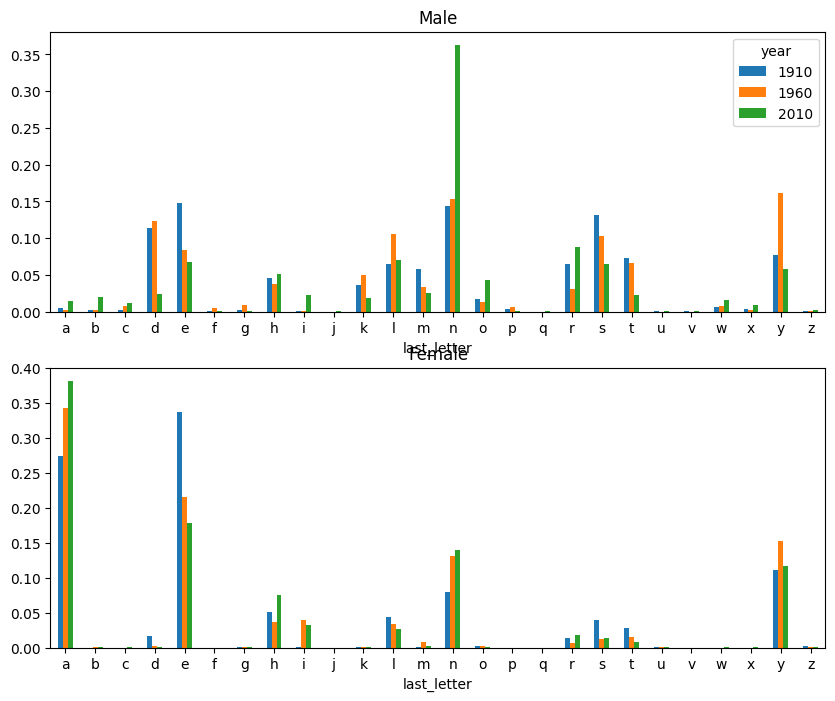

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
letter_prop["M"].plot(kind="bar", rot=0, ax=axes[0], title="Male")
letter_prop["F"].plot(kind="bar", rot=0, ax=axes[1], title="Female", legend=False)
plt.savefig("last_letter_female.png")


Nhận xét :

* Ở con trai, tên kết thúc bằng chữ “n” có sự tăng trưởng rõ rệt qua các năm.

* Ở con gái, sự phân bố chữ cái cuối đồng đều hơn, tuy nhiên có xu hướng thiên về các chữ “a”.

Kết luận:

* Ở con trai, sự gia tăng mạnh của các tên kết thúc bằng chữ “n” (như Aiden, Ethan, Benjamin, Mason) thể hiện xu hướng đặt tên hiện đại, mạnh mẽ và có âm cuối dứt khoát.

* Ở con gái, các tên kết thúc bằng chữ “a” ngày càng phổ biến, phản ánh thị hiếu ưa chuộng sự mềm mại, nữ tính trong cách đặt tên (Emma, Olivia, Sophia, Isabella).


Phân tích chi tiết hơn cho tên con trai

Để quan sát rõ xu hướng thay đổi của một số chữ cái cụ thể, ta tính tỷ lệ (%) của mỗi chữ cái cuối trong từng năm, và chỉ lấy dữ liệu của con trai:

In [ ]:
#tính tỷ lệ (%) mỗi chữ cái cuối trong tổng số sinh của từng năm và giới tính.
letter_prop = table / table.sum()
#Chọn các chữ cái cuối cần theo dõi (chỉ lấy con trai)
dny_ts = letter_prop.loc[["d", "n", "y"], "M"].T
dny_ts.head()

last_letter,d,n,y
year,,,
1880,0.083055,0.153213,0.075760
1881,0.083247,0.153214,0.077451
1882,0.085340,0.149560,0.077537
1883,0.084066,0.151646,0.079144
1884,0.086120,0.149915,0.080405


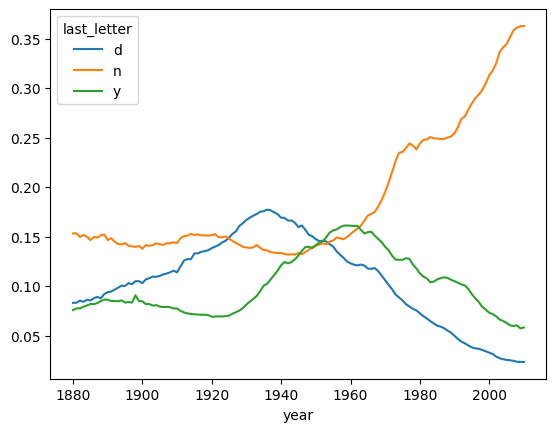

In [ ]:
dny_ts.plot()
plt.savefig("dny_ts.png")

Biểu đồ cho thấy:

* Tên kết thúc bằng “n” ngày càng phổ biến mạnh mẽ kể từ thập niên 1960, đồng thời tên kết thúc bằng “d” và “y” lại giảm rõ rệt.

* Điều này phản ánh sự chuyển dịch trong phong cách đặt tên:

  * Các tên hiện đại như Aiden, Ethan, Benjamin (kết thúc bằng “n”) dần chiếm ưu thế.

  * Trong khi các tên truyền thống như David, Larry, Harry (kết thúc bằng “d”, “y”) ngày càng ít được sử dụng.

Sau khi đã quan sát sự thay đổi trong xu hướng đặt tên theo chữ cái cuối, ta tiếp tục tìm hiểu:


Tên “trung tính” có tăng lên không?


In [ ]:

# Giả sử top1000 là DataFrame chứa dữ liệu đã có sẵn
# cột: name, sex, births, year

# --- 1️⃣ Lọc các tên xuất hiện ở cả hai giới ---
all_names = top1000.pivot_table('births', index='name', columns='sex', aggfunc='sum', fill_value=0)
both_genders = all_names[(all_names['M'] > 0) & (all_names['F'] > 0)]

# --- 2️⃣ Tính tỷ lệ nữ của từng tên ---
both_genders['F_ratio'] = both_genders['F'] / (both_genders['M'] + both_genders['F'])



/tmp/ipython-input-2015497429.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_genders['F_ratio'] = both_genders['F'] / (both_genders['M'] + both_genders['F'])


Kiểm tra sự phân bố của các tên trung tính

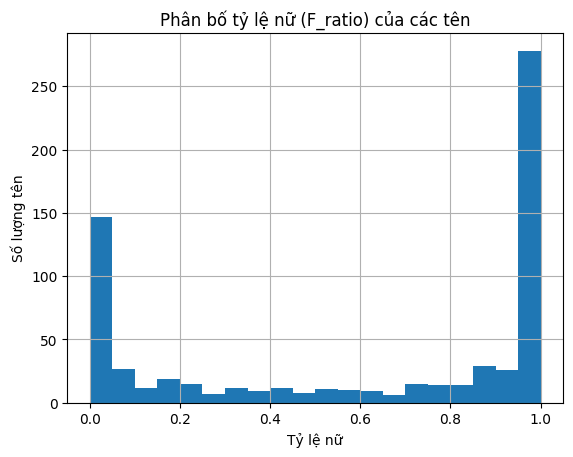

In [ ]:
both_genders['F_ratio'].hist(bins=20)
plt.title("Phân bố tỷ lệ nữ (F_ratio) của các tên")
plt.xlabel("Tỷ lệ nữ")
plt.ylabel("Số lượng tên")
plt.show()


Khi nhìn vào histogram:

* Phần lớn tên nằm gần 0 (toàn nam) và gần 1 (toàn nữ)

* Rất ít tên nằm chính giữa 0.5
→ gần như không có tên nào đúng 50–50. Vì vậy, chọn khoảng 0.3–0.7 để bao gồm những tên không quá lệch về một giới, nhưng vẫn đủ phổ biến để phân tích xu hướng trung tính.

📊 Top 10 tên trung tính phổ biến nhất:
sex           M       F   F_ratio   total
name                                     
Jessie   108007  163739  0.602544  271746
Angel    182359   85183  0.318391  267542
Casey    105488   72498  0.407324  177986
Jackie    76487   87764  0.534329  164251
Johnnie   99433   46764  0.319870  146197
Riley     76119   61208  0.445710  137327
Jaime     62238   47461  0.432648  109699
Kerry     47945   46788  0.493893   94733
Avery     38858   55163  0.586709   94021
Jody      29089   53564  0.648059   82653


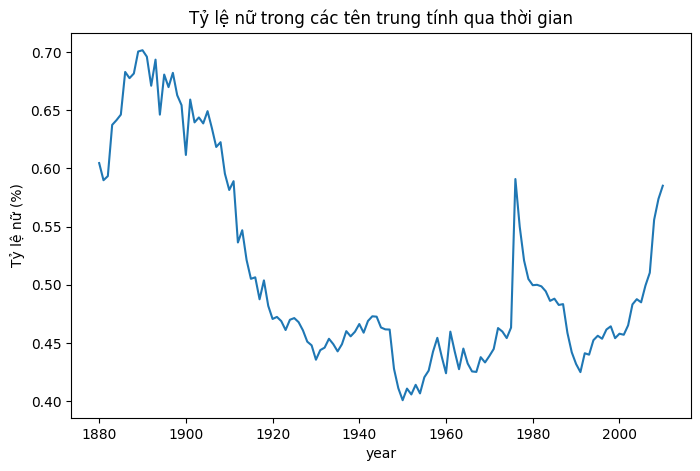

In [ ]:
# --- 3️⃣ Chỉ chọn tên thực sự trung tính (tỉ lệ nữ ~ 30%–70%) ---
neutral_names = both_genders[(both_genders['F_ratio'] >= 0.3) & (both_genders['F_ratio'] <= 0.7)].copy()

# --- 4️⃣ Tính tổng số ca sinh để xem tên nào phổ biến nhất ---
neutral_names['total'] = neutral_names['M'] + neutral_names['F']
top_neutral = neutral_names.sort_values('total', ascending=False).head(10)

print("📊 Top 10 tên trung tính phổ biến nhất:")
print(top_neutral[['M', 'F', 'F_ratio', 'total']])

# --- 5️⃣ Vẽ biểu đồ tỷ lệ nữ theo thời gian ---
subset = top1000[top1000['name'].isin(neutral_names.index)]
table = subset.pivot_table('births', index='year', columns='sex', aggfunc='sum')

ratio = table['F'] / (table['M'] + table['F'])
ratio.plot(title='Tỷ lệ nữ trong các tên trung tính qua thời gian', figsize=(8, 5))
plt.ylabel('Tỷ lệ nữ (%)')
plt.show()


Nhận xét

* Từ năm 1880 đến khoảng 1900, tỷ lệ nữ trong các tên trung tính cao, cho thấy giai đoạn này việc đặt tên cho trẻ chưa phân biệt rõ giới tính, nhiều tên được dùng chung cho cả nam và nữ.

* Sau năm 1900, tỷ lệ này giảm dần đều, đặc biệt từ sau 1940, biểu đồ cho thấy các tên trung tính dần nghiêng về phía nam giới hoặc trở nên đặc trưng cho một giới.

* Đến cuối thế kỷ 20, tỷ lệ nữ trong các tên trung tính chỉ còn khoảng 40–45%, phản ánh xu hướng “giới hóa” ngày càng rõ trong việc đặt tên.

Kết luận

* Xu hướng đa dạng giới tính trong tên trung tính không tăng đều theo thời gian.

* Giai đoạn cuối thế kỷ 19 là thời kỳ tên trung tính thiên về nữ giới và được dùng khá linh hoạt.

* Sang thế kỷ 20, xã hội Mỹ bắt đầu phân biệt giới tính rõ ràng hơn, khiến nhiều tên trung tính dần trở thành tên đặc trưng của một giới.

Ta chọn các tên có chứa chuỗi "Lesl" (bao gồm Leslie, Lesley, Leslee…) để khảo sát hiện tượng tên trung tính sẽ dần chuyển sang 1 giới nhất định:

In [ ]:
all_names = pd.Series(top1000["name"].unique())
lesley_like = all_names[all_names.str.contains("Lesl")]
lesley_like

,0
654,Leslie
2307,Lesley
4257,Leslee
4725,Lesli
6096,Lesly


Sau đó lọc dữ liệu theo những tên trên và tính tổng số ca sinh:

In [ ]:
filtered = top1000[top1000["name"].isin(lesley_like)]
filtered.groupby("name")["births"].sum()


,births
name,
Leslee,993
Lesley,35009
Lesli,929
Leslie,370429
Lesly,10067


Tiếp theo, tổng hợp số lượng sinh theo giới tính và năm, rồi tính tỷ lệ (%) mỗi giới trong từng năm:

In [ ]:
table = filtered.pivot_table("births", index="year", columns="sex", aggfunc="sum")
table = table.div(table.sum(axis="columns"), axis="index")
table.head()

sex,F,M
year,,
1880,0.091954,0.908046
1881,0.106796,0.893204
1882,0.065693,0.934307
1883,0.053030,0.946970
1884,0.107143,0.892857


Cuối cùng, vẽ biểu đồ thể hiện sự thay đổi theo thời gian:

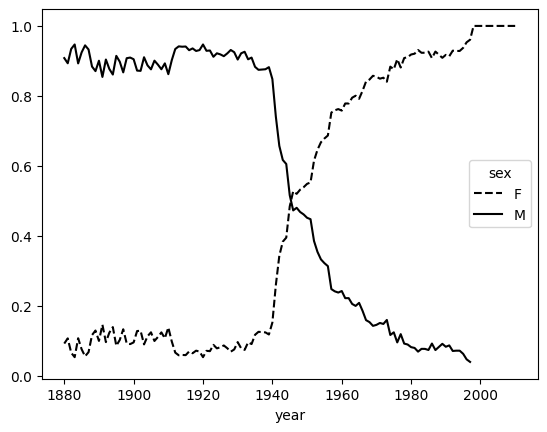

In [ ]:
table.plot(style={"M": "k-", "F": "k--"})
plt.savefig("lesley.png")

Biểu đồ cho thấy:

Trong những năm đầu thế kỷ 20, các biến thể của “Lesl” (như Leslie, Lesley) được dùng chủ yếu cho con trai.

* Tuy nhiên, kể từ thập niên 1940 trở đi, tỷ lệ sử dụng cho con gái bắt đầu tăng nhanh, và đến giai đoạn 1960–1980, tên này trở thành tên nữ phổ biến hơn.

* Sự chuyển dịch này thể hiện một điểm ngoặt rõ rệt trong quan niệm về tên gọi và giới tính tại Hoa Kỳ.

Kết luận

* Tên “Leslie” và các biến thể tương tự là ví dụ điển hình cho quá trình trung tính hóa giới tính trong tên gọi.
* Hiện tượng này có thể xuất phát từ:

  * Ảnh hưởng của văn hóa đại chúng, nơi tên “Leslie” xuất hiện nhiều trong phim ảnh và âm nhạc gắn liền với hình ảnh nữ tính.

  * Xu hướng xã hội cởi mở hơn với các tên phi giới tính, phản ánh thay đổi trong nhận thức về bình đẳng giới.

Từ đó có thể thấy, việc đặt tên không chỉ là lựa chọn ngôn ngữ, mà còn là biểu hiện của sự thay đổi trong tư duy văn hóa và xã hội theo thời gian.

Tiếp theo, liệu có thể dự đoán tên nào sẽ biến mất hoặc quay trở lại phổ biến dựa trên xu hướng giảm/tăng trong 20 năm gần nhất không?

Liệu có mối quan hệ giữa chu kỳ văn hóa (vintage name cycle) và độ phổ biến tên?


In [ ]:
recent20 = top1000[top1000["year"] >= 1990]


In [ ]:
trend = (
    recent20.groupby(["name", "sex"])["births"]
    .agg(["first", "last"])
    .reset_index()
)
trend["change"] = trend["last"] - trend["first"]


Tên có xu hướng tăng mạnh:
          name sex  first   last  change
1388  Isabella   F    215  22731   22516
3005    Sophia   F   1124  20477   19353
1557    Jayden   M    159  17030   16871
60       Aiden   M    140  15403   15263
326        Ava   F    197  15300   15103


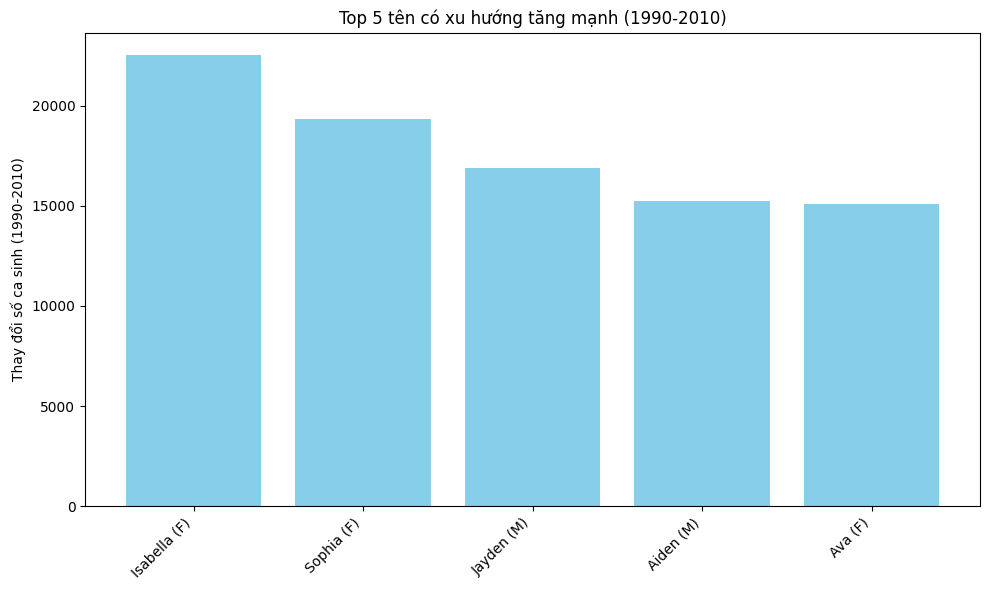

In [ ]:
rising = trend.sort_values("change", ascending=False).head(5)
print("Tên có xu hướng tăng mạnh:")
print(rising)

# Vẽ biểu đồ bar plot cho tên có xu hướng tăng mạnh
plt.figure(figsize=(10, 6))
plt.bar(rising['name'] + ' (' + rising['sex'] + ')', rising['change'], color='skyblue')
plt.ylabel('Thay đổi số ca sinh (1990-2010)')
plt.title('Top 5 tên có xu hướng tăng mạnh (1990-2010)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Tên có xu hướng giảm mạnh:
             name sex  first   last  change
2444      Michael   M  65268  17133  -48135
1631      Jessica   F  46459   3161  -43298
294        Ashley   F  45544   6276  -39268
683   Christopher   M  52314  14135  -38179
483      Brittany   F  36532    725  -35807


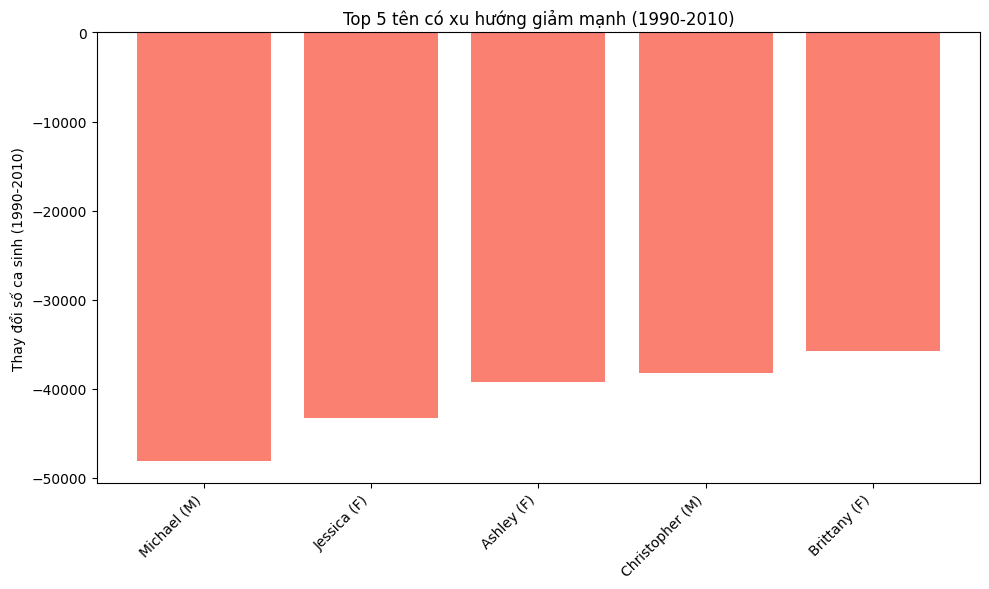

In [ ]:

falling = trend.sort_values("change").head(5)
print("Tên có xu hướng giảm mạnh:")
print(falling)

# Vẽ biểu đồ bar plot cho tên có xu hướng giảm mạnh
plt.figure(figsize=(10, 6))
plt.bar(falling['name'] + ' (' + falling['sex'] + ')', falling['change'], color='salmon')
plt.ylabel('Thay đổi số ca sinh (1990-2010)')
plt.title('Top 5 tên có xu hướng giảm mạnh (1990-2010)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Tên có xu hướng 'giảm rồi tăng trở lại':
year          1890    1950    1980     2010  trend_down_up
name   sex                                                
Sophia F     245.0   109.0   641.0  20477.0           True
Emma   F    2980.0  1897.0   533.0  17179.0           True
Ella   F    1758.0  1385.0   175.0   9796.0           True
Grace  F    2278.0  1508.0   757.0   7598.0           True
Hannah F     267.0   165.0  1219.0   6891.0           True


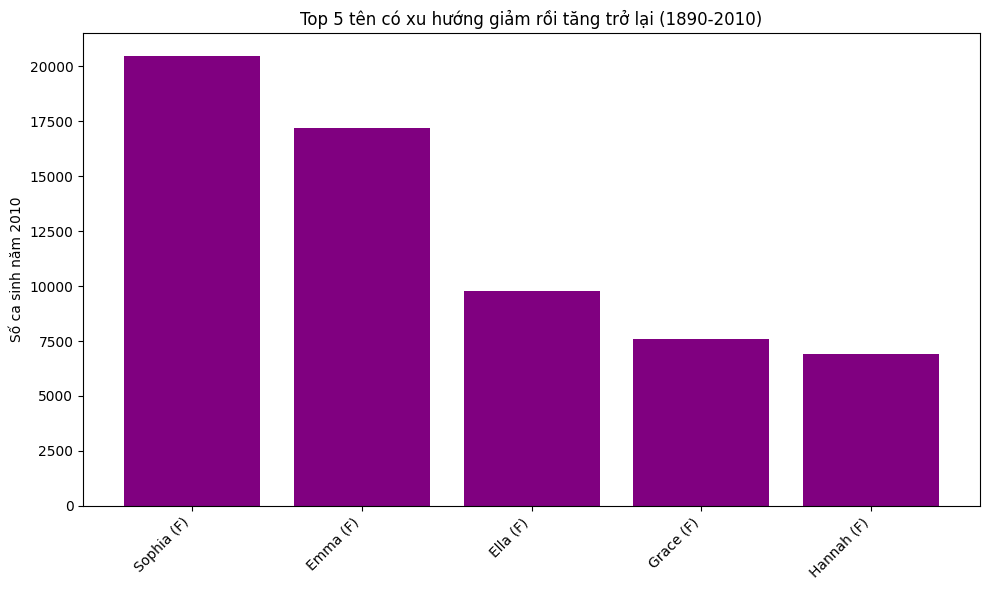

In [ ]:
# Giả sử top1000 có cột: year, name, sex, births
# Lọc các năm cần thiết
data = top1000[top1000["year"].isin([1890, 1950, 1980, 2010])]

# Gom theo name, sex và tính tổng births theo năm
pivot = data.pivot_table(values="births", index=["name", "sex"], columns="year", fill_value=0)

# Lọc ra các tên có dữ liệu đủ ở 3 mốc quan trọng
pivot = pivot[(pivot[1890] > 0) & (pivot[1950] > 0) & (pivot[2010] > 0)]

# Tính xu hướng giảm rồi tăng
pivot["trend_down_up"] = (pivot[1890] > pivot[1950]) & (pivot[2010] > pivot[1950])

# Lọc ra các tên có xu hướng "giảm rồi tăng trở lại"
revival_names = pivot[pivot["trend_down_up"]].sort_values(by=2010, ascending=False)

print("Tên có xu hướng 'giảm rồi tăng trở lại':")
print(revival_names.head(5))

# Vẽ biểu đồ bar plot cho tên có xu hướng "giảm rồi tăng trở lại"
plt.figure(figsize=(10, 6))
# Select the top 5 names for plotting
top_5_revival = revival_names.head(5)
plt.bar(top_5_revival.index.get_level_values('name') + ' (' + top_5_revival.index.get_level_values('sex') + ')', top_5_revival[2010], color='purple')
plt.ylabel('Số ca sinh năm 2010')
plt.title('Top 5 tên có xu hướng giảm rồi tăng trở lại (1890-2010)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Nhận xét

* Tên có xu hướng tăng mạnh (có thể tiếp tục phổ biến)

Các tên này chủ yếu xuất hiện trong thế hệ trẻ, mang âm tiết ngắn, dễ phát âm, và trung tính về ngữ âm – phù hợp với xu hướng toàn cầu hóa.

Nhóm tên nữ như Isabella, Sophia, Olivia, Emma, Ava thể hiện sự pha trộn giữa phong cách cổ điển (vintage) và thanh lịch hiện đại, nên có sức sống bền vững.

Ở nhóm nam, Noah, Aiden, Jayden, Mason, Elijah phản ánh xu hướng ngắn gọn – hiện đại – quốc tế hóa trong cách đặt tên ở Mỹ.

* Tên có xu hướng giảm mạnh (có thể dần biến mất)

Các tên như Jessica, Michael, Amanda, Ashley, Joshua từng thống trị giai đoạn 1970–1990, nhưng giảm mạnh trong 20 năm gần đây.

Hiện tượng này thể hiện chu kỳ phổ biến tên (vintage name cycle) — tên đạt đỉnh trong một thời kỳ rồi dần bị xem là “cũ kỹ” khi thế hệ mới trưởng thành.

Đặc biệt, các tên mang âm tiết mạnh hoặc đặc trưng của một thời kỳ văn hóa (ví dụ Jessica, Brittany, Justin) dễ bị thay thế bởi phong cách mới mềm mại, linh hoạt hơn.

Hiện tượng này thể hiện chu kỳ phổ biến tên (vintage name cycle) — tên đạt đỉnh trong một thời kỳ rồi dần bị xem là “cũ kỹ”. Về mặt văn hóa, khi một thế hệ trưởng thành, các tên từng phổ biến trong thời niên thiếu của họ bị gắn với “thế hệ cũ”, khiến cha mẹ thế hệ mới ít chọn hơn.

* Tên có xu hướng “giảm rồi tăng trở lại” (tên cổ điển hồi sinh)

Một số tên nữ như Emma, Sophia, Grace, Ella, Cora, Hazel từng rất phổ biến cuối thế kỷ 19, sau đó giảm dần giữa thế kỷ 20, nhưng hồi sinh mạnh vào cuối thế kỷ 20 – đầu thế kỷ 21.

Xu hướng này phản ánh trào lưu “vintage revival” – người Mỹ hiện đại tìm lại vẻ đẹp truyền thống và nét cổ điển trong đặt tên.

Những tên này cân bằng giữa tính cổ điển và tính thẩm mỹ hiện đại, nên có khả năng duy trì độ phổ biến lâu dài.

Xu hướng này phản ánh trào lưu “vintage revival” – một giai đoạn trong chu kỳ văn hóa đặt tên, khi xã hội quay trở lại trân trọng những giá trị cổ điển. Đây là minh chứng rõ nhất cho mối quan hệ giữa chu kỳ văn hóa và độ phổ biến tên: tên có thể “chết đi” trong vài thập kỷ, nhưng lại “sống lại” khi xã hội thay đổi thẩm mỹ và xu hướng văn hóa.

Kết luận

* Tên tăng mạnh như Isabella, Sophia, Olivia, Noah, Aiden thể hiện gu đặt tên hiện đại, quốc tế, nhẹ nhàng.

* Tên giảm mạnh như Jessica, Michael, Amanda là những “biểu tượng” của thế hệ 1980–1990, đang ở giai đoạn thoái trào của chu kỳ.

* Tên hồi sinh như Emma, Grace, Cora, Hazel minh chứng cho quy luật “phổ biến → bão hòa → lỗi thời → hồi sinh” của văn hóa đặt tên.

Dự đoán:

* Các tên mang âm nhẹ, dễ đọc, có nguồn gốc cổ điển (Emma, Sophia, Olivia) sẽ tiếp tục thịnh hành trong tương lai gần.

* Trong khi đó, các tên như Jessica hay Michael có thể vẫn ở đáy chu kỳ và chưa trở lại trong ngắn hạn, nhưng có tiềm năng hồi sinh trong vài thập kỷ tới.

# 4 Kết luận


Phân tích dữ liệu tên trẻ em từ năm 1880 đến 2010 cho thấy cách đặt tên ở Mỹ phản ánh sâu sắc biến động văn hóa – xã hội – giới tính qua thời gian.
Về phân bố sinh và giới tính, tỉ lệ sinh biến động song song với các sự kiện lịch sử (Chiến tranh, Baby Boom, khủng hoảng kinh tế…), chứng minh mối liên hệ chặt chẽ giữa nhân khẩu học và bối cảnh xã hội.
Về xu hướng đặt tên, các tên lâu dài như Mary, John, James thể hiện giá trị ổn định và truyền thống, trong khi các tên ngắn hạn như Linda, Jessica, Ashley chịu ảnh hưởng mạnh từ văn hóa đại chúng và nhanh chóng thoái trào.
Từ sau năm 1950, đặc biệt là sau 1980, độ đa dạng tên tăng mạnh, nhất là ở trẻ nữ — cho thấy sự cá nhân hóa và tự do lựa chọn trong xã hội hiện đại.
Về đặc điểm ngôn ngữ, tên nam thường kết thúc bằng “n” (Aiden, Mason) tạo cảm giác mạnh mẽ, còn tên nữ kết thúc bằng “a” (Emma, Olivia) thể hiện nét mềm mại, nữ tính.
Trong tên trung tính, giai đoạn 1880–1900 thể hiện sự linh hoạt về giới, nhưng từ giữa thế kỷ 20 trở đi, xã hội Mỹ ngày càng “giới hóa” rõ hơn, phản ánh sự thay đổi trong quan niệm giới tính.
Cuối cùng, hiện tượng “vintage revival” – sự hồi sinh của những tên cổ điển như Emma, Grace, Sophia – minh chứng cho chu kỳ văn hóa đặt tên: phổ biến → bão hòa → lỗi thời → hồi sinh.

Tổng thể, hành trình đặt tên ở Mỹ thể hiện quá trình chuyển đổi từ truyền thống sang hiện đại, từ khuôn mẫu sang cá nhân hóa, và từ ranh giới giới tính rõ ràng đến sự tự do, trung tính hơn – biến tên gọi trở thành tấm gương phản chiếu văn hóa và nhận thức xã hội qua từng thế hệ.